# Logistic Regression Visualization & From-Scratch Implementation

This notebook uses the shared `xai_book.plotting` palette so the chapter keeps one visual language. Blue marks class 0, orange marks class 1, and chapter gray is reserved for neutral guides, titles, and annotations.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

NOTEBOOK_SLUG = "logistic_regression"
OUT_DIR = Path("out") / NOTEBOOK_SLUG
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename: str) -> Path:
    return OUT_DIR / filename

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, IntSlider, interact
from sklearn.linear_model import LogisticRegression

from xai_book.plotting import (
    BLUE,
    CHAPTER_GRAY,
    GRID,
    NOTEBOOK_LABEL_SIZE,
    NOTEBOOK_LEGEND_SIZE,
    NOTEBOOK_SQUARE_FIGSIZE,
    NOTEBOOK_TICK_SIZE,
    NOTEBOOK_TITLE_SIZE,
    ORANGE,
    apply_plot_style,
    blue_orange_cmap,
    display_and_save_figure,
)

CLASS_COLORS = {0: BLUE, 1: ORANGE}
PROBABILITY_CMAP = blue_orange_cmap("book_probability_surface")

def make_logistic_blobs(n_samples: int, seed: int):
    rng = np.random.default_rng(seed)
    cov = np.array([[1.0, 0.75], [0.75, 1.0]])
    class_zero = rng.multivariate_normal([0.0, 0.0], cov, n_samples)
    class_one = rng.multivariate_normal([1.5, 1.5], cov, n_samples)
    features = np.vstack([class_zero, class_one])
    targets = np.hstack([np.zeros(n_samples, dtype=int), np.ones(n_samples, dtype=int)])
    return features, targets, class_zero, class_one


def make_probability_grid(features, step: float = 0.02, pad: float = 1.0):
    x_min, x_max = features[:, 0].min() - pad, features[:, 0].max() + pad
    y_min, y_max = features[:, 1].min() - pad, features[:, 1].max() + pad
    return np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))


def style_logistic_axis(ax, *, title: str):
    ax.set_title(title, fontsize=NOTEBOOK_TITLE_SIZE, color=CHAPTER_GRAY, pad=14)
    ax.set_xlabel(r"Feature $x_1$", fontsize=NOTEBOOK_LABEL_SIZE, color=CHAPTER_GRAY)
    ax.set_ylabel(r"Feature $x_2$", fontsize=NOTEBOOK_LABEL_SIZE, color=CHAPTER_GRAY)
    ax.tick_params(axis="both", labelsize=NOTEBOOK_TICK_SIZE, colors=CHAPTER_GRAY)
    ax.grid(True, color=GRID, linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)


def add_probability_colorbar(fig, ax, contour):
    colorbar = fig.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label(r"$P(y=1 \mid x)$", fontsize=NOTEBOOK_LABEL_SIZE, color=CHAPTER_GRAY)
    colorbar.ax.tick_params(labelsize=NOTEBOOK_TICK_SIZE, colors=CHAPTER_GRAY)
    return colorbar


def make_logistic_boundary_figure(*, xx, yy, surface, X0, X1, title: str, summary_lines: list[str]):
    apply_plot_style(figsize=NOTEBOOK_SQUARE_FIGSIZE)

    fig, ax = plt.subplots()
    contour = ax.contourf(
        xx,
        yy,
        surface,
        levels=np.linspace(0.0, 1.0, 21),
        cmap=PROBABILITY_CMAP,
        alpha=0.88,
    )
    ax.contour(xx, yy, surface, levels=[0.5], colors=CHAPTER_GRAY, linewidths=1.6, linestyles="--")
    ax.scatter(
        X0[:, 0],
        X0[:, 1],
        s=70,
        color=CLASS_COLORS[0],
        edgecolors="white",
        linewidth=0.9,
        label="Class 0",
    )
    ax.scatter(
        X1[:, 0],
        X1[:, 1],
        s=70,
        marker="s",
        color=CLASS_COLORS[1],
        edgecolors="white",
        linewidth=0.9,
        label="Class 1",
    )
    style_logistic_axis(ax, title=title)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
        fontsize=NOTEBOOK_LEGEND_SIZE,
        columnspacing=1.2,
        handletextpad=0.4,
    )

    ax.text(
        0.03,
        0.97,
        "\n".join(summary_lines),
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=NOTEBOOK_TICK_SIZE,
        color=CHAPTER_GRAY,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=GRID),
    )
    fig.subplots_adjust(bottom=0.2)
    add_probability_colorbar(fig, ax, contour)
    return fig


## 1. Interactive fit with scikit-learn

In [2]:
def render_logistic(C=1.0, n_samples=50, seed=0):
    X, y, X0, X1 = make_logistic_blobs(n_samples=n_samples, seed=seed)
    model = LogisticRegression(C=C, solver="lbfgs")
    model.fit(X, y)

    xx, yy = make_probability_grid(X)
    surface = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    accuracy = model.score(X, y)

    fig = make_logistic_boundary_figure(
        xx=xx,
        yy=yy,
        surface=surface,
        X0=X0,
        X1=X1,
        title=rf"Logistic decision surface for $C={C:.2f}$",
        summary_lines=[
            rf"$\hat{{w}}_1 = {model.coef_[0, 0]:.2f}$",
            rf"$\hat{{w}}_2 = {model.coef_[0, 1]:.2f}$",
            rf"$\hat{{b}} = {model.intercept_[0]:.2f}$",
            rf"$\mathrm{{accuracy}} = {accuracy:.2f}$",
        ],
    )
    display_and_save_figure(fig, out_path("logistic_regression_interactive_latest.pdf"), tight_layout=False)


In [3]:
interact(
    render_logistic,
    C=FloatSlider(min=0.01, max=10.0, step=0.01, value=1.0, description=r"$C$:"),
    n_samples=IntSlider(min=10, max=200, step=10, value=50, description="Samples:"),
    seed=IntSlider(min=0, max=100, step=1, value=0, description="Seed:"),
)


interactive(children=(FloatSlider(value=1.0, description='$C$:', max=10.0, min=0.01, step=0.01), IntSlider(val…

<function __main__.render_logistic(C=1.0, n_samples=50, seed=0)>

## 2. From-scratch gradient descent

Iteration    0 - Loss: 0.6931
Iteration  500 - Loss: 0.3951
Iteration 1000 - Loss: 0.3938
Iteration 1500 - Loss: 0.3936
Iteration 2000 - Loss: 0.3936
Iteration 2500 - Loss: 0.3936
Iteration 3000 - Loss: 0.3936
Iteration 3500 - Loss: 0.3936
Iteration 4000 - Loss: 0.3936
Iteration 4500 - Loss: 0.3936


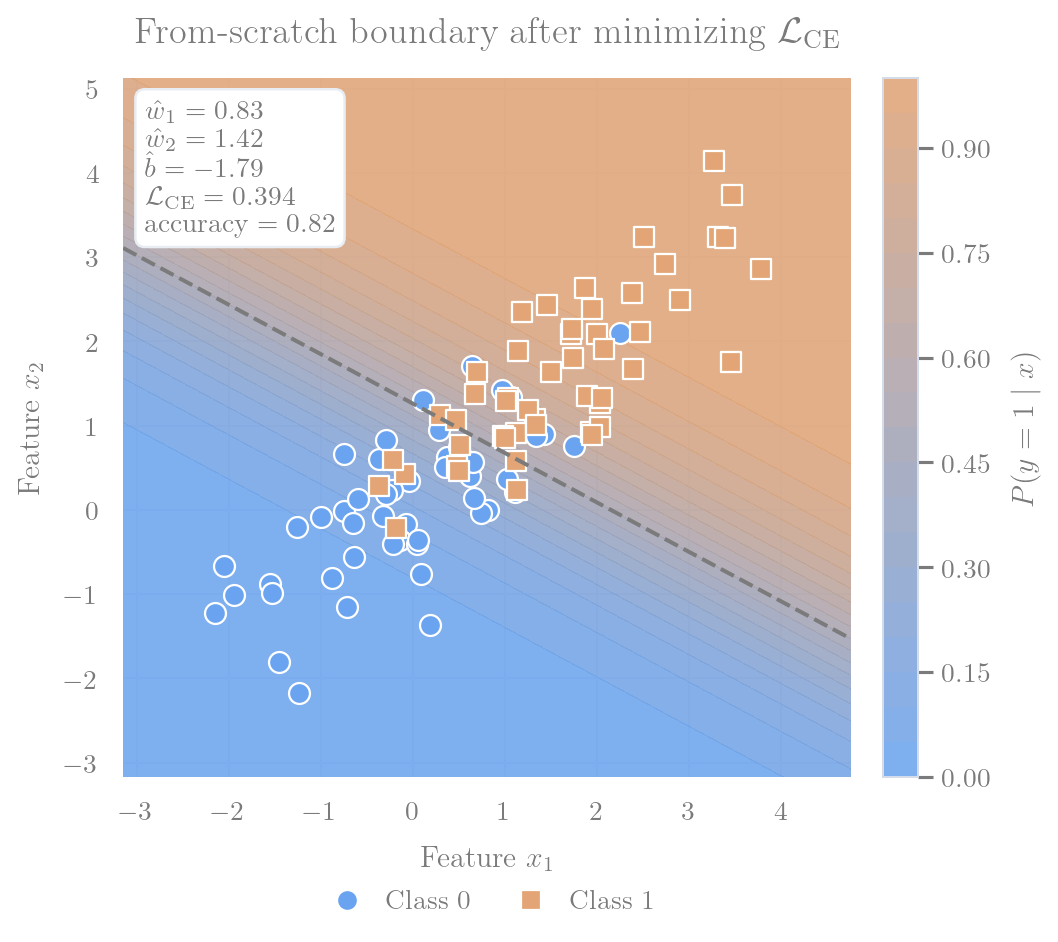

PosixPath('out/logistic_regression/logistic_regression_from_scratch.pdf')

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def cross_entropy_loss(y_true, y_pred):
    eps = 1e-15
    p = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))


X, y, X0, X1 = make_logistic_blobs(n_samples=50, seed=0)
X_bias = np.column_stack([np.ones(X.shape[0]), X])
weights = np.zeros(X_bias.shape[1])
learning_rate = 0.1
n_iterations = 5000
loss_history = []

for iteration in range(n_iterations):
    logits = X_bias @ weights
    predictions = sigmoid(logits)
    gradient = X_bias.T @ (predictions - y) / y.size
    weights -= learning_rate * gradient
    loss = cross_entropy_loss(y, predictions)
    loss_history.append(loss)
    if iteration % 500 == 0:
        print(f"Iteration {iteration:4d} - Loss: {loss:.4f}")

xx, yy = make_probability_grid(X)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_bias = np.column_stack([np.ones(grid.shape[0]), grid])
surface = sigmoid(grid_bias @ weights).reshape(xx.shape)
train_accuracy = ((sigmoid(X_bias @ weights) >= 0.5).astype(int) == y).mean()

fig = make_logistic_boundary_figure(
    xx=xx,
    yy=yy,
    surface=surface,
    X0=X0,
    X1=X1,
    title=r"From-scratch boundary after minimizing $\mathcal{L}_{\mathrm{CE}}$",
    summary_lines=[
        rf"$\hat{{w}}_1 = {weights[1]:.2f}$",
        rf"$\hat{{w}}_2 = {weights[2]:.2f}$",
        rf"$\hat{{b}} = {weights[0]:.2f}$",
        rf"$\mathcal{{L}}_{{\mathrm{{CE}}}} = {loss_history[-1]:.3f}$",
        rf"$\mathrm{{accuracy}} = {train_accuracy:.2f}$",
    ],
)
display_and_save_figure(fig, out_path("logistic_regression_from_scratch.pdf"), tight_layout=False)
